# Keypoint Combining – MediaPipe & MoveNet

1. MediaPipe visibility ≥ 0.6 → use MediaPipe
2. MoveNet confidence ≥ 0.6, not interpolated → use MoveNet
3. Else → missing (NaN), rescued by GPR in later step

In [53]:
from pathlib import Path
import pandas as pd
import numpy as np
import cv2
import re

IN_DIR      = Path('../data/processed/keypoints_interpolated_boundary')
CROPPED_DIR = Path('../data/processed/keypoints_cropped')
VIDEO_DIR   = Path('../data/original/Utvalda filminspelningar för IRAF analys/Dec 2025 sit-stå och stå-sitt')
OUT_CSV     = Path('../data/processed/keypoints_combined')
OUT_VIDEO   = Path('../data/processed/keypoints_combined_videos')

FPS            = 50
THRESHOLD_HIGH = 0.6
THRESHOLD_LOW  = 0.3

time_dict = {
    '028': (9.90,  11.77), '030': (5.80,  7.63),
    '045': (6.54,   7.98), '047': (7.03,  8.91),
    '059': (6.65,   9.11), '061': (6.00,  9.00),
    '074': (6.07,   7.27), '076': (5.00,  8.00),
    '091': (6.39,   7.61), '093': (5.86,  7.67),
}

JOINTS = [
    'left_shoulder', 'right_shoulder',
    'left_elbow',    'right_elbow',
    'left_wrist',    'right_wrist',
    'left_hip',      'right_hip',
    'left_knee',     'right_knee',
    'left_ankle',    'right_ankle',
]

COLOR_MEDIAPIPE = (255, 80,  80)   # blue
COLOR_MOVENET   = (80,  200, 80)   # green
COLOR_GPR       = (0,   165, 255)  # orange

OUT_CSV.mkdir(parents=True, exist_ok=True)
OUT_VIDEO.mkdir(parents=True, exist_ok=True)

## Combining function

In [54]:
def combine_keypoints(df_mp, df_mn):
    combined = df_mp.copy()

    for joint in JOINTS:
        mp_vis    = df_mp[f'{joint}_visibility'].values
        mn_conf   = df_mn[f'{joint}_confidence'].values
        mn_interp = df_mn[f'{joint}_interpolated'].values if f'{joint}_interpolated' in df_mn.columns else np.ones(len(df_mn), dtype=bool)

        mp_missing  = mp_vis < THRESHOLD_HIGH
        mn_good     = (mn_conf >= THRESHOLD_HIGH) & (~mn_interp.astype(bool))
        use_movenet = mp_missing & mn_good

        for coord in ['x', 'y']:
            combined.loc[use_movenet, f'{joint}_{coord}'] = df_mn.loc[use_movenet, f'{joint}_{coord}'].values

        combined[f'{joint}_source'] = 'mediapipe'
        combined.loc[use_movenet, f'{joint}_source'] = 'movenet'

        still_missing = mp_missing & ~mn_good
        combined.loc[still_missing, f'{joint}_source'] = 'missing'
        combined.loc[still_missing, f'{joint}_x'] = np.nan
        combined.loc[still_missing, f'{joint}_y'] = np.nan

    return combined

## Combine and save

In [55]:
for mp_path in sorted((IN_DIR / 'mediapipe_norm').glob('*.csv')):
    video_id = mp_path.stem.replace('_mediapipe_norm', '')
    mn_path  = IN_DIR / 'movenet' / f'{video_id}_movenet.csv'

    if not mn_path.exists():
        print(f'  no MoveNet match for {video_id}, skipping')
        continue

    df_mp = pd.read_csv(mp_path)
    df_mn = pd.read_csv(mn_path)

    n          = min(len(df_mp), len(df_mn))
    df_combined = combine_keypoints(df_mp.iloc[:n].reset_index(drop=True),
                                    df_mn.iloc[:n].reset_index(drop=True))

    df_combined.to_csv(OUT_CSV / f'{video_id}.csv', index=False)
    print(f'{video_id}: {n} frames saved')

DJI_20250425092743_0028_D: 94 frames saved
DJI_20250425093100_0030_D: 92 frames saved
DJI_20250425104507_0045_D: 73 frames saved
DJI_20250425104804_0047_D: 94 frames saved
DJI_20250425112502_0059_D: 123 frames saved
DJI_20250425112749_0061_D: 151 frames saved
DJI_20250425120835_0074_D: 60 frames saved
DJI_20250425121226_0076_D: 151 frames saved
DJI_20250425125202_0091_D: 61 frames saved
DJI_20250425125448_0093_D: 91 frames saved


## Missing joints before GPR

In [56]:
before_rows = []
for csv_path in sorted(OUT_CSV.glob('*.csv')):
    df = pd.read_csv(csv_path)
    for joint in JOINTS:
        src_col = f'{joint}_source'
        if src_col not in df.columns:
            continue
        counts = df[src_col].value_counts()
        before_rows.append({
            'video':          csv_path.stem,
            'joint':          joint,
            'missing_before': counts.get('missing', 0),
            'total_frames':   len(df),
        })

missing_before = pd.DataFrame(before_rows)
total_before   = missing_before['missing_before'].sum()

print(f'Missing before GPR: {total_before} frames')
only_missing = missing_before[missing_before['missing_before'] > 0][['video', 'joint', 'missing_before', 'total_frames']]
print(only_missing.to_string(index=False))

Missing before GPR: 666 frames
                    video       joint  missing_before  total_frames
DJI_20250425092743_0028_D right_elbow              23            94
DJI_20250425092743_0028_D  left_wrist              22            94
DJI_20250425092743_0028_D right_wrist              74            94
DJI_20250425093100_0030_D right_elbow              10            92
DJI_20250425093100_0030_D right_wrist              23            92
DJI_20250425104507_0045_D right_elbow              28            73
DJI_20250425104507_0045_D right_wrist              69            73
DJI_20250425104804_0047_D right_elbow              16            94
DJI_20250425104804_0047_D right_wrist              28            94
DJI_20250425112502_0059_D right_elbow              15           123
DJI_20250425112502_0059_D  left_wrist              40           123
DJI_20250425112502_0059_D right_wrist              49           123
DJI_20250425112502_0059_D right_ankle               1           123
DJI_2025042511274

## GPR Rescue, conf 0.3-0.6

For missing joints:
1. Copy coords from `keypoints_cropped` if conf 0.3-0.6 → flag `low_confidence`
2. Fit GP per joint: high-conf frames as anchors, low-conf as noisy observations
3. Predict `low_confidence` + short missing gaps (≤ MAX_GAP_FILL) → source = `gpr`

In [57]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel

NOISE_HIGH   = 1e-3
NOISE_LOW    = 0.10
MAX_GAP_FILL = 30


def make_kernel():
    return (ConstantKernel(1.0)
            * RBF(length_scale=5.0, length_scale_bounds=(1.0, 50.0))
            + WhiteKernel(noise_level=NOISE_HIGH, noise_level_bounds=(1e-5, 0.5)))


def find_short_gaps(src_arr, max_gap):
    missing = src_arr == 'missing'
    result  = np.zeros(len(src_arr), dtype=bool)
    i = 0
    while i < len(src_arr):
        if missing[i]:
            j = i
            while j < len(src_arr) and missing[j]:
                j += 1
            if (j - i) <= max_gap:
                result[i:j] = True
            i = j
        else:
            i += 1
    return result


def refine_joint_gpr(df, joint):
    src_col = f'{joint}_source'
    x_col   = f'{joint}_x'
    y_col   = f'{joint}_y'

    src = df[src_col].values
    t   = np.arange(len(df), dtype=float)

    mask_high = np.isin(src, ['mediapipe', 'movenet'])
    mask_low  = src == 'low_confidence'
    mask_fill = find_short_gaps(src, MAX_GAP_FILL)

    if mask_high.sum() < 3 or (mask_low | mask_fill).sum() == 0:
        return df

    mask_train = mask_high | mask_low
    t_train    = t[mask_train]
    alpha      = np.where(mask_high[mask_train], NOISE_HIGH, NOISE_LOW)

    for coord_col in [x_col, y_col]:
        y_train = df[coord_col].values.astype(float)[mask_train]
        if np.any(np.isnan(y_train)):
            continue

        gpr = GaussianProcessRegressor(
            kernel=make_kernel(), alpha=alpha,
            n_restarts_optimizer=3, normalize_y=True,
        )
        gpr.fit(t_train.reshape(-1, 1), y_train)

        if mask_low.sum() > 0:
            y_pred, _ = gpr.predict(t[mask_low].reshape(-1, 1), return_std=True)
            df.loc[mask_low, coord_col] = y_pred

        if mask_fill.sum() > 0:
            y_pred_fill, _ = gpr.predict(t[mask_fill].reshape(-1, 1), return_std=True)
            df.loc[mask_fill, coord_col] = y_pred_fill

    if mask_low.sum() > 0:
        df.loc[mask_low,  src_col] = 'gpr'
    if mask_fill.sum() > 0:
        df.loc[mask_fill, src_col] = 'gpr'

    return df

In [58]:
cr_mn_dir = CROPPED_DIR / 'movenet'
cr_mp_dir = CROPPED_DIR / 'mediapipe_norm'

for csv_path in sorted(OUT_CSV.glob('*.csv')):
    df       = pd.read_csv(csv_path)
    video_id = csv_path.stem

    mn_cr_path = cr_mn_dir / f'{video_id}_movenet.csv'
    mp_cr_path = cr_mp_dir / f'{video_id}_mediapipe_norm.csv'
    if not mn_cr_path.exists() or not mp_cr_path.exists():
        continue

    df_mn_cr = pd.read_csv(mn_cr_path)
    df_mp_cr = pd.read_csv(mp_cr_path)
    n        = min(len(df), len(df_mn_cr), len(df_mp_cr))
    df       = df.iloc[:n].reset_index(drop=True)
    df_mn_cr = df_mn_cr.iloc[:n].reset_index(drop=True)
    df_mp_cr = df_mp_cr.iloc[:n].reset_index(drop=True)

    rescued = []
    for joint in JOINTS:
        src_col = f'{joint}_source'
        if src_col not in df.columns:
            continue

        missing_mask = df[src_col] == 'missing'
        if missing_mask.sum() == 0:
            continue

        # copy 0.3-0.6 conf coords from keypoints_cropped
        mp_vis  = df_mp_cr[f'{joint}_visibility'].values
        mn_conf = df_mn_cr[f'{joint}_confidence'].values
        mp_low  = (mp_vis  >= THRESHOLD_LOW) & (mp_vis  < THRESHOLD_HIGH)
        mn_low  = (mn_conf >= THRESHOLD_LOW) & (mn_conf < THRESHOLD_HIGH)

        use_mp_low = missing_mask & mp_low
        use_mn_low = missing_mask & ~mp_low & mn_low

        if (use_mp_low | use_mn_low).sum() > 0:
            for coord in ['x', 'y']:
                df.loc[use_mp_low, f'{joint}_{coord}'] = df_mp_cr.loc[use_mp_low, f'{joint}_{coord}'].values
                df.loc[use_mn_low, f'{joint}_{coord}'] = df_mn_cr.loc[use_mn_low, f'{joint}_{coord}'].values
            df.loc[use_mp_low | use_mn_low, src_col] = 'low_confidence'

        # GPR: refines low_confidence + fills short missing gaps
        df = refine_joint_gpr(df, joint)

        n_gpr = (df[src_col] == 'gpr').sum()
        if n_gpr > 0:
            rescued.append(f'{joint}:{n_gpr}')

    df.to_csv(csv_path, index=False)

    if rescued:
        print(f'{video_id}: GPR rescued {", ".join(rescued)}')
    else:
        print(f'{video_id}: no rescuable frames')

/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/sklearn/gaussian_process/kernels.py:420: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/sklearn/gaussian_process/kernels.py:420: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/sklearn/gaussian_process/kernels.py:420: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  w

DJI_20250425092743_0028_D: GPR rescued right_elbow:23, left_wrist:22, right_wrist:74


/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/sklearn/gaussian_process/kernels.py:420: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


DJI_20250425093100_0030_D: GPR rescued right_elbow:10, right_wrist:23


/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/sklearn/gaussian_process/kernels.py:420: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/sklearn/gaussian_process/kernels.py:420: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


...

/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/sklearn/gaussian_process/kernels.py:420: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/sklearn/gaussian_process/kernels.py:420: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


DJI_20250425125202_0091_D: GPR rescued right_wrist:48


/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/sklearn/gaussian_process/kernels.py:420: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/sklearn/gaussian_process/kernels.py:420: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


DJI_20250425125448_0093_D: GPR rescued right_elbow:6, right_wrist:12


/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/sklearn/gaussian_process/kernels.py:420: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


## Videos

- Blue   = MediaPipe
- Green  = MoveNet
- Orange = GPR rescued

In [59]:
def draw_joints(frame, row, h, w):
    for joint in JOINTS:
        x = row.get(f'{joint}_x')
        y = row.get(f'{joint}_y')
        if pd.isna(x) or pd.isna(y):
            continue
        src = row.get(f'{joint}_source')
        if src == 'movenet':
            color = COLOR_MOVENET
        elif src == 'gpr':
            color = COLOR_GPR
        else:
            color = COLOR_MEDIAPIPE
        cv2.circle(frame, (int(x * w), int(y * h)), 7, color, -1)
        cv2.circle(frame, (int(x * w), int(y * h)), 7, (0, 0, 0), 1)
    return frame


for csv_path in sorted(OUT_CSV.glob('*.csv')):
    match = re.search(r'_0(\d{3})_D', csv_path.stem)
    if not match:
        continue
    vid_id    = match.group(1)
    vid_files = list(VIDEO_DIR.glob(f'*_0{vid_id}_D.MP4'))

    if not vid_files:
        print(f'Video not found: {vid_id}')
        continue

    df  = pd.read_csv(csv_path)
    cap = cv2.VideoCapture(str(vid_files[0]))
    cap.set(cv2.CAP_PROP_POS_FRAMES, int(time_dict[vid_id][0] * FPS))

    w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    out_path = OUT_VIDEO / f'{csv_path.stem}.mp4'
    writer   = cv2.VideoWriter(str(out_path), cv2.VideoWriter_fourcc(*'avc1'), FPS, (w, h))

    for i, row in df.iterrows():
        ret, frame = cap.read()
        if not ret:
            break
        frame = draw_joints(frame, row, h, w)
        writer.write(frame)

    cap.release()
    writer.release()
    print(f'{vid_id}: video saved')

028: video saved
030: video saved
045: video saved
047: video saved
059: video saved
061: video saved
074: video saved
076: video saved
091: video saved
093: video saved


## Before vs After GPR

Before: 666 missing frames
After:  0 missing frames
Rescued: 666 (100.0%)

                    video       joint  missing_before  gpr  missing_after  rescued
DJI_20250425092743_0028_D right_elbow              23   23              0       23
DJI_20250425092743_0028_D  left_wrist              22   22              0       22
DJI_20250425092743_0028_D right_wrist              74   74              0       74
DJI_20250425093100_0030_D right_elbow              10   10              0       10
DJI_20250425093100_0030_D right_wrist              23   23              0       23
DJI_20250425104507_0045_D right_elbow              28   28              0       28
DJI_20250425104507_0045_D right_wrist              69   69              0       69
DJI_20250425104804_0047_D right_elbow              16   16              0       16
DJI_20250425104804_0047_D right_wrist              28   28              0       28
DJI_20250425112502_0059_D right_elbow              15   15              0       15
DJI_20250425

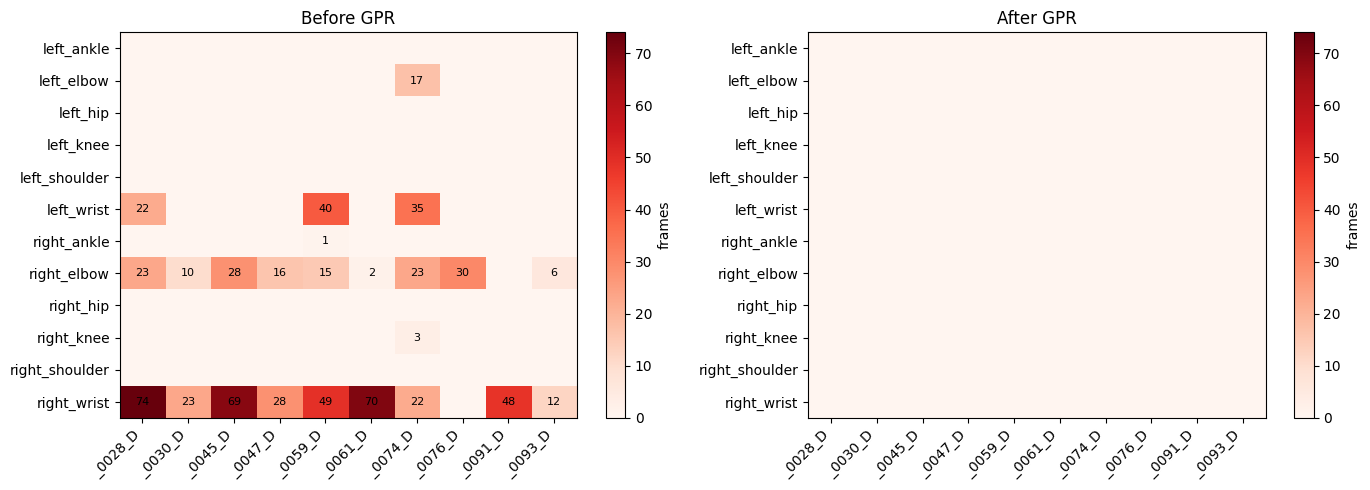

In [60]:
import matplotlib.pyplot as plt

after_rows = []
for csv_path in sorted(OUT_CSV.glob('*.csv')):
    df = pd.read_csv(csv_path)
    for joint in JOINTS:
        src_col = f'{joint}_source'
        if src_col not in df.columns:
            continue
        counts = df[src_col].value_counts()
        after_rows.append({
            'video':         csv_path.stem,
            'joint':         joint,
            'missing_after': counts.get('missing', 0),
            'gpr':           counts.get('gpr', 0),
        })

missing_after = pd.DataFrame(after_rows)
total_after   = missing_after['missing_after'].sum()

comp = missing_before.merge(missing_after, on=['video', 'joint'])
comp['rescued'] = comp['missing_before'] - comp['missing_after']

print(f'Before: {total_before} missing frames')
print(f'After:  {total_after} missing frames')
print(f'Rescued: {total_before - total_after} ({(total_before - total_after) / max(total_before, 1) * 100:.1f}%)')
print()

changed = comp[comp['rescued'] != 0][['video', 'joint', 'missing_before', 'gpr', 'missing_after', 'rescued']]
if changed.empty:
    print('No frames rescued.')
else:
    print(changed.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(max(8, len(comp['video'].unique()) * 1.4), 5))
for ax, col, title in zip(axes,
                           ['missing_before', 'missing_after'],
                           ['Before GPR', 'After GPR']):
    pivot = comp.pivot(index='joint', columns='video', values=col).fillna(0).astype(int)
    im = ax.imshow(pivot.values, aspect='auto', cmap='Reds',
                   vmin=0, vmax=comp['missing_before'].max())
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels([c[-7:] for c in pivot.columns], rotation=45, ha='right')
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            v = pivot.values[i, j]
            if v > 0:
                ax.text(j, i, str(v), ha='center', va='center', fontsize=8)
    ax.set_title(title)
    plt.colorbar(im, ax=ax, label='frames')

plt.tight_layout()
plt.show()